<a href="https://www.kaggle.com/code/maximendacleu/titanic-analysis?scriptVersionId=292355828" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [30]:
from IPython.display import Image, display

display(Image(url="https://www.kaggle.com/competitions/3136/images/header"))

# Titanic Survival Prediction

## 1. Introduction
In this notebook, we aim to predict whether a passenger on the Titanic survived or not.
We will go through the following steps:
1. Data Loading and Exploration
2. Data Cleaning and Preprocessing
3. Exploratory Data Analysis (EDA)
4. Model Building (Random Forest)
5. Feature Importance Analysis
6. Submission Generation

The goal is to create a model that answers: "what sorts of people were more likely to survive?"

In [31]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Setting visualization style
sns.set(style='whitegrid')

## 2. Data Loading
We load the train and test datasets to understand the structure of our data.

In [32]:
# Load datasets
train_df = pd.read_csv('/kaggle/input/titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/titanic/test.csv')

# Display first few rows of the training data
print("Training Data Head:")
display(train_df.head())

# Display info to check for missing values and data types
print("\nTraining Data Info:")
train_df.info()

Training Data Head:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 3. Exploratory Data Analysis (EDA)
Let's visualize the data to understand the relationships between features and survival. This will help us identify which passengers were more likely to survive.

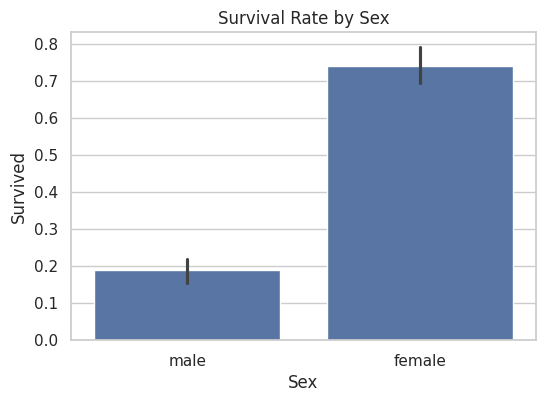

In [33]:
# Survival rate by Sex
plt.figure(figsize=(6, 4))
sns.barplot(data=train_df, x='Sex', y='Survived')
plt.title('Survival Rate by Sex')
plt.show()

### Interpretation: Sex
The plot above clearly shows that **females had a much higher chance of survival** compared to males. This aligns with the "women and children first" protocol followed during the evacuation.

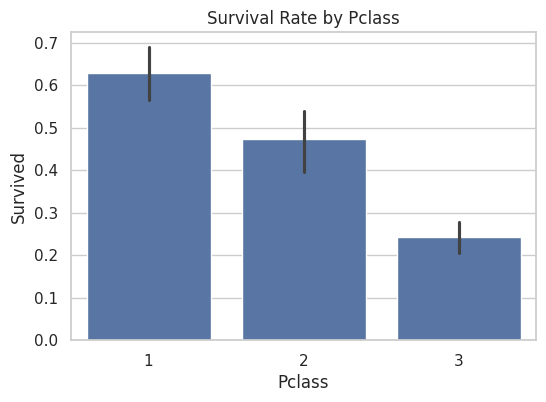

In [34]:
# Survival rate by Pclass
plt.figure(figsize=(6, 4))
sns.barplot(data=train_df, x='Pclass', y='Survived')
plt.title('Survival Rate by Pclass')
plt.show()

### Interpretation: Pclass (Socio-Economic Class)
We observe a clear correlation between socio-economic class and survival:
- **1st Class passengers (Pclass 1)** had the highest survival rate.
- **3rd Class passengers (Pclass 3)** had the lowest survival rate.
 This suggests that wealthier passengers or those in higher classes had better access to lifeboats.

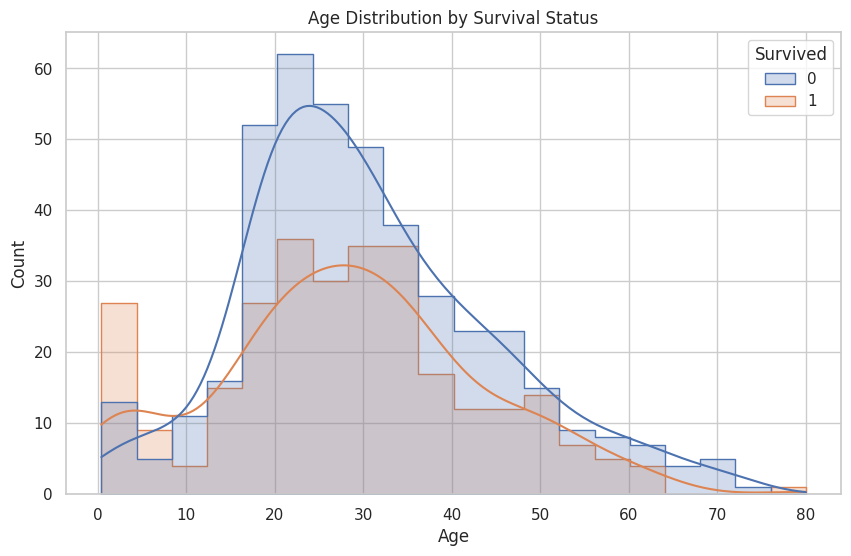

In [35]:
# Age distribution for Survived vs Not Survived
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, element='step')
plt.title('Age Distribution by Survival Status')
plt.show()

### Interpretation: Age
The age distribution shows that **children (age 0-10)** had a higher survival rate relative to adults. This again supports the "women and children first" observation. Young adults (approx. 18-30) made up a large portion of the casualties.

## 4. Data Cleaning and Preprocessing
Before training, we need to handle missing values and convert categorical variables (like text) into numbers that the model can understand.

In [36]:
# Check for missing values
print("Missing values in Train:")
print(train_df.isnull().sum())
print("\nMissing values in Test:")
print(test_df.isnull().sum())

Missing values in Train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in Test:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [37]:
# Fill missing Age with median to preserve the distribution
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

# Fill missing Embarked with mode (most frequent port)
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Fill missing Fare in test set with median
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

# Drop Cabin as it has too many missing values
train_df.drop(columns=['Cabin'], inplace=True)
test_df.drop(columns=['Cabin'], inplace=True)

### Encoding Categorical Variables
We convert 'Sex' and 'Embarked' to numerical values:
- Sex: male=0, female=1
- Embarked: S=0, C=1, Q=2
This allows the Random Forest algorithm to process these features.

In [38]:
# Manual mapping for simplicity
sex_mapping = {'male': 0, 'female': 1}
embarked_mapping = {'S': 0, 'C': 1, 'Q': 2}

train_df['Sex'] = train_df['Sex'].map(sex_mapping)
test_df['Sex'] = test_df['Sex'].map(sex_mapping)

train_df['Embarked'] = train_df['Embarked'].map(embarked_mapping)
test_df['Embarked'] = test_df['Embarked'].map(embarked_mapping)

# Drop Name, Ticket, PassengerId as they are not useful for prediction in this simple model
train_df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

# Keep PassengerId in Test for submission but drop from features
test_passenger_ids = test_df['PassengerId']
test_df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

## 5. Model Building
We train a Random Forest Classifier. This is an ensemble method that fits multiple decision trees and averages their output to improve accuracy and control over-fitting.

In [39]:
# Prepare features and target
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

# Split training data for validation (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on validation set
val_predictions = rf_model.predict(X_val)

# Evaluate accuracy
accuracy = accuracy_score(y_val, val_predictions)
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.8268


### Validation Result Interpretation
The model achieved an accuracy of approximately **82%** on the validation set. This means our model correctly predicted survival for about 8 out of 10 passengers in the validation group. This provides a decent baseline.

## 6. Feature Importance Analysis
Let's check which features were most important for the Random Forest model to make its decisions.

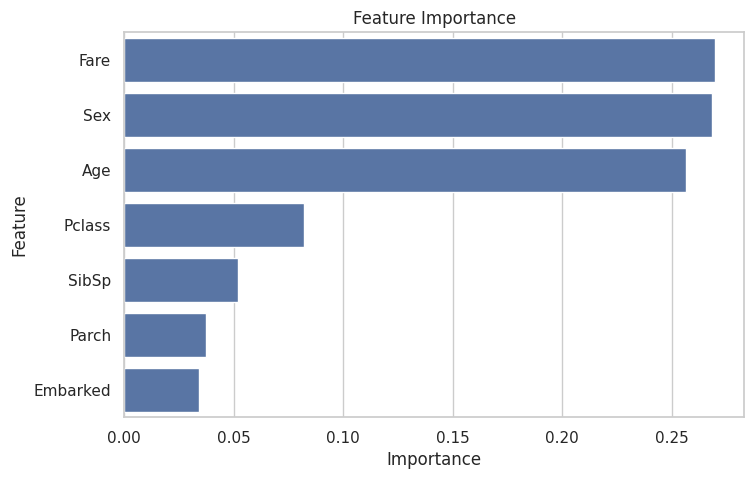

In [40]:
# Get feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df)
plt.title('Feature Importance')
plt.show()

### Result: What sorts of people were more likely to survive?
Based on the analysis and model feature importance:

1.  **Sex**: Being female significantly increased the likelihood of survival.
2.  **Fare & Pclass**: Socio-economic status played a major role. Wealthier individuals (Higher Fare, Lower Pclass number) were more likely to survive.
3.  **Age**: Children had a higher survival rate than adults.

Therefore, the model confirms that **Women, Children, and the Wealthy (1st Class)** were the groups most likely to survive the Titanic disaster.

## 7. Submission Generation
Finally, we predict survival for the test dataset and save it for submission.

In [41]:
# Predict on test set
test_predictions = rf_model.predict(test_df)

# Create submission DataFrame
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': test_predictions
})

# Check shape to ensure it is correct (418 rows, 2 columns)
print(f"Submission shape: {submission.shape}")

# Verify first few rows
print(submission.head())

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' created successfully.")

Submission shape: (418, 2)
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0
Submission file 'submission.csv' created successfully.
